In [2]:
#Colab ONLY!
#from google.colab import output

#Colab ONLY!
##!pip install torch sounddevice numpy
##!pip install -U transformers

from transformers import pipeline
from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq, WhisperProcessor, WhisperForConditionalGeneration, pipeline

from pathlib import Path
from IPython.display import Audio, display, Javascript
from base64 import b64decode

import time
import io
import numpy as np
import pandas as pd
import scipy.io.wavfile as wavfile

import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf
import subprocess

import torch, gc

C:\Users\veikk\PycharmProjects\NeuronetworkTasks\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Voice recognition in Finnish Language

I will be testing pre-trained Wisper voice recognitions models to compare and see how they perform when analysing spoken finnish language. I am starting by declaring the model settings for later use and then creating the recording function. 

In [3]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Device: {device}")

Device: cpu


In [4]:
AUDIO_DIR = Path("./audio_samples")

audio_samples = [
    {"id": "1", "filename": "vantaa.wav", "desc": "Clean Finnish speech", "lang": "fi"},
    {"id": "2", "filename": "me_opiskelemme.wav", "desc": "Clean Finnish speech", "lang": "fi"},
]

pd.DataFrame(audio_samples)

,id,filename,desc,lang
0,1,vantaa.wav,Clean Finnish speech,fi
1,2,me_opiskelemme.wav,Clean Finnish speech,fi


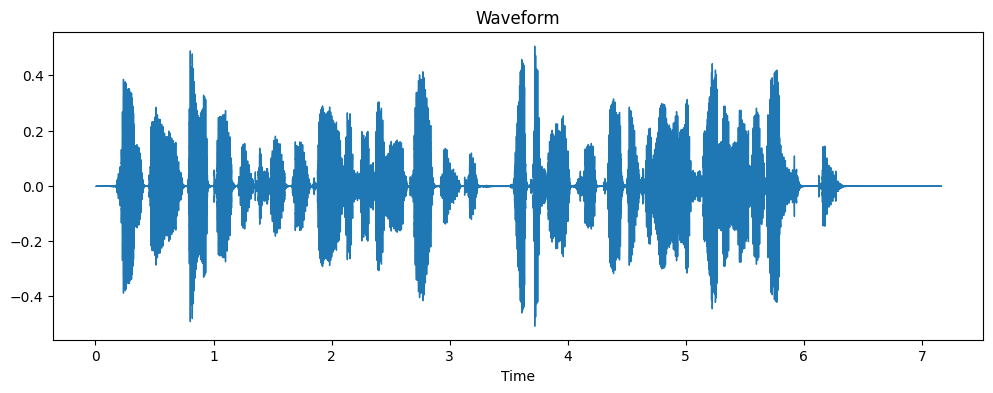

In [5]:
sample = audio_samples[0]
path = AUDIO_DIR / sample["filename"]

y, sr = librosa.load(path, sr=16000)

display(Audio(y, rate=sr))

plt.figure(figsize=(12,4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.show()

### Recording function

This is only usable in Google Colab, as it uses the browser's media recording capabilities. The function records audio for a specified duration, saves it as a webm file, converts it to wav format using ffmpeg, and then reads the audio data into memory for further processing.

In [ ]:
audio_data = None

def _on_audio(data_b64):
    global audio_data
    audio_data = b64decode(data_b64)
    with open("recording.webm", "wb") as f:
        f.write(audio_data)
    subprocess.run(["ffmpeg", "-y", "-i", "recording.webm", "-ar", "16000", "-ac", "1", "recording.wav"])
    print("Recording saved and converted.")

output.register_callback('notebook.on_audio', _on_audio)

def record_audio(seconds=5):
    display(Javascript(f'''
    (async function() {{
        const stream = await navigator.mediaDevices.getUserMedia({{audio: true}});
        const recorder = new MediaRecorder(stream);
        const chunks = [];

        recorder.ondataavailable = e => chunks.push(e.data);
        recorder.start();

        await new Promise(r => setTimeout(r, {seconds} * 1000));
        recorder.stop();

        await new Promise(r => recorder.onstop = r);
        stream.getTracks().forEach(t => t.stop());

        const blob = new Blob(chunks, {{type: 'audio/webm'}});
        const reader = new FileReader();
        reader.readAsDataURL(blob);
        await new Promise(r => reader.onloadend = r);

        const b64 = reader.result.split(',')[1];
        google.colab.kernel.invokeFunction('notebook.on_audio', [b64], {{}});
    }})();
    '''))
    print(f"Recording for {seconds} seconds... Speak now!")

record_audio(seconds=5)

### Visualisation

After the recording has completed, it will output .wav recording, so the librosa is able to properly load the audio file. The audio is then loaded as a Waveform and a Mel-Spectorgram.

In the spectogram X-axis showcases the time of the recording, to visualise where certain sounds happen.

Y-axis showcases the sound frequency on the mel scale, hence the name. This filters out sounds that humans are not able to hear.

The colors on the spectogram determine the Decibels or the loudness of the sound at the given moment. The DB is higher with warmer colors, while quiter when showing colder colors.

Audio length: 114600 samples, max amplitude: 0.5075


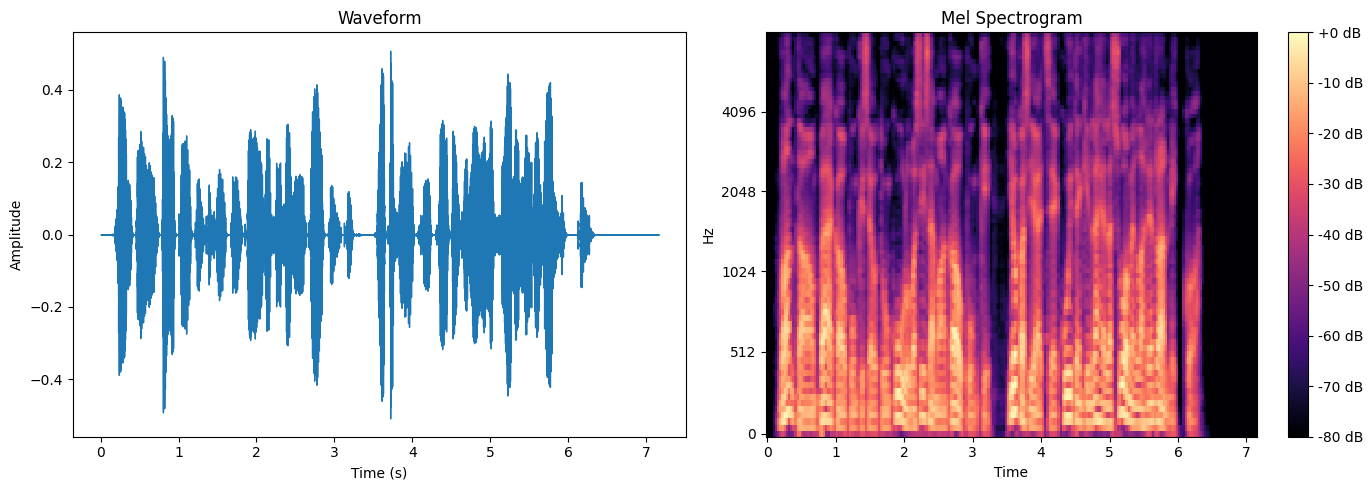

In [6]:
audio, sr = librosa.load(path, sr=16000)
print(f"Audio length: {len(audio)} samples, max amplitude: {np.max(np.abs(audio)):.4f}")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
librosa.display.waveshow(audio, sr=sr)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.subplot(1, 2, 2)
mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=80)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
librosa.display.specshow(mel_spec_db, sr=sr, x_axis="time", y_axis="mel")
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")

plt.tight_layout()
plt.show()

In [7]:
_model_cache = {}

def load_model(size):
    if size in _model_cache:
        return _model_cache[size]

    name = f"openai/whisper-{size}"
    processor = WhisperProcessor.from_pretrained(name)
    model = WhisperForConditionalGeneration.from_pretrained(name).to(device)

    _model_cache[size] = (processor, model)
    return processor, model


def transcribe(path, size, lang):
    processor, model = load_model(size)

    y, sr = librosa.load(path, sr=16000)
    inputs = processor(y, sampling_rate=sr, return_tensors="pt")

    start = time.perf_counter()

    with torch.no_grad():
        ids = model.generate(inputs.input_features.to(device), language=lang)

    elapsed = time.perf_counter() - start

    text = processor.batch_decode(ids, skip_special_tokens=True)[0]

    return {
        "model": size,
        "time": elapsed,
        "text": text
    }

In [8]:
models = ["tiny", "base", "large"]

results = []

for s in audio_samples:
    path = AUDIO_DIR / s["filename"]

    for m in models:
        if not path.exists():
            continue

        res = transcribe(path, m, s["lang"])
        res["sample"] = s["id"]
        results.append(res)

df = pd.DataFrame(results)
df

C:\Users\veikk\PycharmProjects\NeuronetworkTasks\.venv\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\veikk\.cache\huggingface\hub\models--openai--whisper-tiny. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
The attention mask is not set and cannot be inferred from input because pad token is same as e

,model,time,text,sample
0,tiny,2.405935,Vanta on pääkaupunkiseutun kuuluvasisemaan ka...,1
1,base,3.836268,Vantaan pääkaupunkiseutun kuuluvat sisämaan k...,1
2,large,68.058513,Vantaa on pääkaupunkiseutuun kuuluva sisämaan...,1
3,tiny,3.985626,Me opiskelemmetropoliassa tieto ja viestintä ...,2
4,base,9.549382,Me opiskelemme metropoliassa tieto ja viestin...,2
5,large,72.883174,Me opiskelemme metropoliassa tieto- ja viesti...,2
